# Package

In [34]:
from ISLP import load_data
from ISLP.models import summarize, ModelSpec as MS
import statsmodels.api as sm
from ISLP.models import contrast
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

# Import Data

In [5]:
Bike = load_data('Bikeshare')

In [6]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

We have 8645 observations and 15 variables

# Linear Regression

In [16]:
X = MS (
    [
        'mnth',
        'hr',
        'workingday',
        'temp',
        'weathersit',
    ]).fit_transform(Bike)

Y = Bike ['bikers']

M_lm = sm.OLS(Y,X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


16 more riders on March than january. 

In [19]:
hr_encore = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

In [20]:
X2 = MS([mnth_encode,
        hr_encore,
        'workingday',
        'temp',
        'weathersit']).fit_transform(Bike)
M2_lm = sm.OLS(Y, X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


The first coefficient means 46 fewer riders than the yearly average. January VS trend of all month. 

In [24]:
np.sum((M_lm.fittedvalues - M2_lm.fittedvalues)**2)

np.float64(4.844666422825268e-20)

In [25]:
coef_month = S2[S2.index.str.contains('mnth')]['coef']
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

In [ ]:
# Decemeber is the negative of all month
months = Bike['mnth'].dtype.categories
coef_month = pd.concat([
    coef_month,
    pd.Series([-coef_month.sum()],
              index = ['mnth[Dec]'])
])
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth[Dec]       0.3705
dtype: float64

Text(0, 0.5, 'Coefficient')

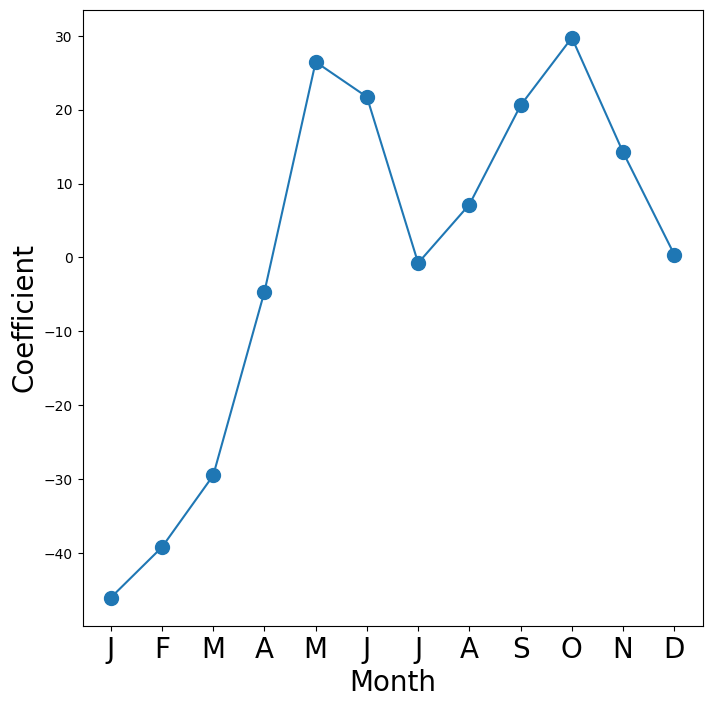

In [36]:
# Decemeber is the negative of all month
fig_month, ax_month = subplots(figsize = (8,8))
x_month = np.arange(coef_month.shape[0])
ax_month.plot(x_month, coef_month, marker = 'o', ms = 10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize = 20)
ax_month.set_xlabel('Month', fontsize = 20)
ax_month.set_ylabel('Coefficient', fontsize = 20)

Comparatively to January, the number of Readers increase until Mai. They are 30 riders more than january. 

In [ ]:
coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr = coef_hr.reindex(['hr[{0}]'.format(h) for h in range(23)])
coef_hr = pd.concat([coef_hr, pd.Series([-coef_hr.sum()], index=['hr[23]'])
])

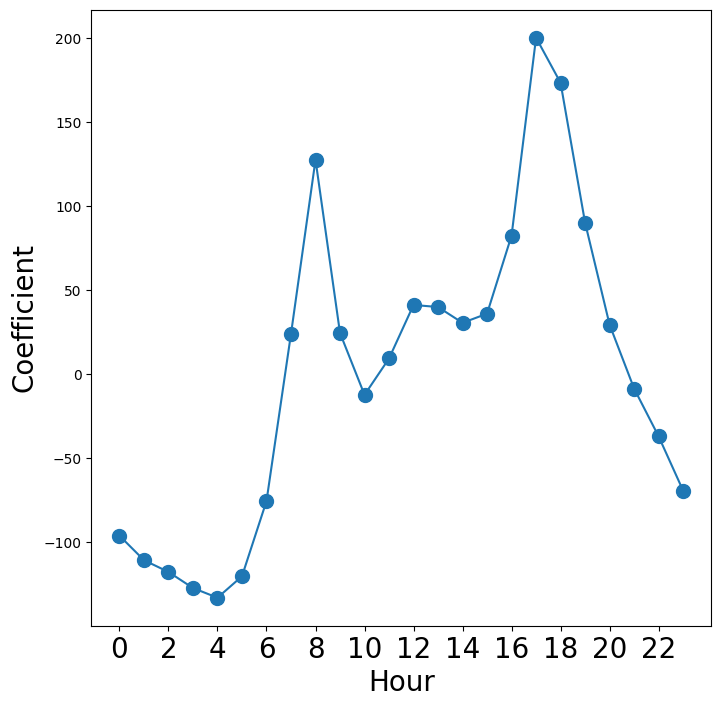

In [39]:
fig_hr, ax_hr = subplots(figsize=(8,8))
x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20);

The number of riders are at his maximum at 8 am and 6 pm. 